In [1]:
import pandas as pd
import itertools
import statsmodels.api as sm
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [ ]:
def exhaustive_regression(X, y, categorical_target=False, alpha=0.1):
    """
    Uses:
      - OLS for continuous targets
      - MNLogit for multiclass categorical targets

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix
    y : pd.Series
        Target vector
    categorical_target : bool
        If True, force treating y as categorical.
    alpha : float
        Significance level for flagging after Bonferroni correction.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame with feature1, feature2, model type,
        interaction coefficients, raw p-values, Bonferroni-adjusted p-values,
        and boolean indicator of significance after correction.
    """
    feature_names = X.columns.tolist()

    # Detect target type
    if categorical_target:
        model_type = "multiclass"
        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        classes = le.classes_
    else:
        if pd.api.types.is_numeric_dtype(y):
            model_type = "continuous"
            y_enc = y.values
        else:
            model_type = "multiclass"
            le = LabelEncoder()
            y_enc = le.fit_transform(y)
            classes = le.classes_

    results = []

    for f1, f2 in itertools.combinations(range(X.shape[1]), 2):
        # Build design matrix
        fname1 = feature_names[f1]
        fname2 = feature_names[f2]
        feature_pair = X[[fname1, fname2]].copy()
        feature_pair["interaction"] = X[fname1] * X[fname2]
        feature_pair = sm.add_constant(feature_pair)

        try:
            if model_type == "continuous":
                # Ordinary Least Squares
                model = sm.OLS(y_enc, feature_pair).fit()
                pval = model.pvalues.get("interaction", np.nan)
                coef = model.params.get("interaction", np.nan)
                results.append({
                    "feature1": fname1,
                    "feature2": fname2,
                    "model": "OLS",
                    "class": None,
                    "interaction_coef": coef,
                    "interaction_pval": pval
                })
            else:
                # Multinomial Logistic Regression
                model = sm.MNLogit(y_enc, feature_pair).fit(disp=False)
                # model.params and model.pvalues are DataFrames indexed by parameter name,
                # columns correspond to classes (0..K-1)
                if "interaction" in model.pvalues.index:
                    # iterate columns (class indices)
                    for class_idx in model.pvalues.columns:
                        pval = model.pvalues.loc["interaction", class_idx]
                        coef = model.params.loc["interaction", class_idx]
                        # map class_idx (int) to actual class label if available
                        class_label = classes[class_idx] if 'classes' in locals() else class_idx
                        results.append({
                            "feature1": fname1,
                            "feature2": fname2,
                            "model": "MNLogit",
                            "class": class_label,
                            "interaction_coef": coef,
                            "interaction_pval": pval
                        })
                else:
                    # No interaction parameter found in results (unexpected), append NaNs
                    results.append({
                        "feature1": fname1,
                        "feature2": fname2,
                        "model": "MNLogit",
                        "class": None,
                        "interaction_coef": np.nan,
                        "interaction_pval": np.nan
                    })

        except Exception as e:
            # keep record of the failure — interaction_pval left as NaN
            results.append({
                "feature1": fname1,
                "feature2": fname2,
                "model": model_type,
                "class": None,
                "interaction_coef": np.nan,
                "interaction_pval": np.nan,
                "error": str(e)
            })

    results_df = pd.DataFrame(results)

    ## bonferonni correction
    
    # Count number of tests performed (non-NaN p-values)
    m = results_df["interaction_pval"].notna().sum()

    # If no tests completed, return early
    if m == 0:
        results_df["interaction_pval_bonf"] = np.nan
        results_df["bonf_significant"] = False
        return results_df

    # Bonferroni adjustment: p_adjusted = min(1, p * m)
    results_df["interaction_pval_bonf"] = results_df["interaction_pval"].apply(
        lambda p: min(1.0, p * m) if pd.notna(p) else np.nan
    )

    # Flag significance after Bonferroni correction
    results_df["bonf_significant"] = results_df["interaction_pval_bonf"].apply(
        lambda p: bool(p < alpha) if pd.notna(p) else False
    )

    # Optional: also include raw alpha threshold flag for convenience
    results_df["raw_significant"] = results_df["interaction_pval"].apply(
        lambda p: bool(p < alpha) if pd.notna(p) else False
    )

    # Add metadata about number of tests and alpha used
    results_df.attrs["n_tests"] = int(m)
    results_df.attrs["alpha"] = float(alpha)

    return results_df

In [ ]:
from scipy.stats import chi2
import warnings

def _zscore_and_clip(s, clip_sds=8.0, eps=1e-12):
    m = float(np.nanmean(s))
    v = float(np.nanvar(s))
    sd = np.sqrt(v) if v > 0 else 1.0
    z = (s - m) / (sd + eps)
    return np.clip(z, -clip_sds, clip_sds)


def exhaustive_regression_full(
    X, y, categorical_target=False, alpha=0.05, stabilize=True, min_per_class=3
):
    """
    Fit one joint model with all main effects and all pairwise interactions,
    then test each interaction coefficient individually with Bonferroni correction.

    For:
      - continuous y: OLS t-tests
      - binary y: Logit z-tests (Wald)
      - multiclass y: MNLogit joint z-tests per interaction (L2 norm)

    Returns:
        DataFrame with interaction effects, p-values, Bonferroni correction, significance.
    """
    X = X.copy()
    y = pd.Series(y).copy()
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X.loc[mask], y.loc[mask]

    feats = X.columns.tolist()
    n = X.shape[0]

    # --- Determine target kind ---
    if not categorical_target and pd.api.types.is_numeric_dtype(y):
        target_kind = "continuous"
        y_vec = y.to_numpy(dtype=float)
    else:
        le = LabelEncoder()
        y_enc = le.fit_transform(y.to_numpy())
        target_kind = "binary" if np.unique(y_enc).size == 2 else "multiclass"
        y_vec = y_enc

    # --- Build design matrix ---
    X_main = X.copy()
    inter_terms = []
    inter_names = []

    for i, j in itertools.combinations(range(X.shape[1]), 2):
        name = f"{feats[i]}×{feats[j]}"
        inter = X.iloc[:, i] * X.iloc[:, j]
        if stabilize:
            inter = _zscore_and_clip(inter)
        inter_terms.append(inter)
        inter_names.append(name)

    if inter_terms:
        X_inter = pd.concat(inter_terms, axis=1)
        X_inter.columns = inter_names
        X_full = pd.concat([X_main, X_inter], axis=1)
    else:
        X_full = X_main.copy()

    X_full = sm.add_constant(X_full, has_constant="add")

    # --- Fit full model ---
    try:
        if target_kind == "continuous":
            model = sm.OLS(y_vec, X_full).fit()
            pvals = model.pvalues
            coefs = model.params
            inter_pvals = pvals[inter_names]
            inter_coefs = coefs[inter_names]
        elif target_kind == "binary":
            model = sm.Logit(y_vec, X_full).fit(disp=False)
            pvals = model.pvalues
            coefs = model.params
            inter_pvals = pvals[inter_names]
            inter_coefs = coefs[inter_names]
        else:  # multiclass
            with warnings.catch_warnings():
                warnings.filterwarnin


In [2]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.multitest import multipletests

def exhaustive_interaction_regression(X, y, alpha=0.1):
    """
    Fit a regression model with all main effects and all pairwise interactions,
    then test significance of interaction terms with Bonferroni correction.
    
    Parameters
    ----------
    X : pd.DataFrame
        Predictor variables (n_samples x n_features)
    y : array-like or pd.Series
        Continuous or categorical target variable
    alpha : float, optional
        Significance level for Bonferroni correction (default=0.05)
        
    Returns
    -------
    results_df : pd.DataFrame
        DataFrame with each interaction term, coefficient, p-value,
        Bonferroni-corrected p-value, and significance flag.
    model_result : statsmodels result object
        The fitted statsmodels model result.
    """
    X = X.copy()
    feature_names = list(X.columns)

    # add all interactions to X
    interaction_dfs = []
    interaction_names = []

    for i, j in itertools.combinations(feature_names, 2):
        inter_name = f"{i}:{j}"
        interaction_dfs.append(pd.Series(X[i] * X[j], name=inter_name))
        interaction_names.append(inter_name)

    X_inter = pd.concat(interaction_dfs, axis=1)
    X = pd.concat([X, X_inter], axis=1)
    
    # what regression type
    y = np.asarray(y)
    unique_classes = np.unique(y)
    is_multiclass = len(unique_classes) > 2
    is_binary = len(unique_classes) == 2
    
    # intercept
    X_const = add_constant(X, has_constant='add')
    
    # fit models
    if is_multiclass:
        model = sm.MNLogit(y, X_const)
    elif is_binary:
        model = sm.Logit(y, X_const)
    else:
        model = sm.OLS(y, X_const)
    
    result = model.fit(disp=False)
    
    # get interaction term pvalue
    pvals = result.pvalues.loc[interaction_names]
    betas = result.params.loc[interaction_names]
    
    # bonf correction
    reject, pvals_corr, _, _ = multipletests(pvals, alpha=alpha, method='bonferroni')
    
    # results
    results_df = pd.DataFrame({
        "interaction": interaction_names,
        "beta": betas,
        "p_value": pvals,
        "p_value_corrected": pvals_corr,
        "significant_bonferroni": reject
    }).sort_values("p_value")
    
    return results_df, result


In [3]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2
import warnings

def _zscore_and_clip(s, clip_sds=8.0, eps=1e-12):
    m = float(np.nanmean(s))
    v = float(np.nanvar(s))
    sd = np.sqrt(v) if v > 0 else 1.0
    z = (s - m) / (sd + eps)
    return np.clip(z, -clip_sds, clip_sds)


def exhaustive_regression_full(
    X, y, categorical_target=False, alpha=0.05, stabilize=True, min_per_class=3
):
    """
    Fit one joint model with all main effects and all pairwise interactions,
    then test each interaction coefficient individually with Bonferroni correction.

    For:
      - continuous y: OLS t-tests
      - binary y: Logit z-tests (Wald)
      - multiclass y: MNLogit joint z-tests per interaction (L2 norm)

    Returns:
        DataFrame with interaction effects, p-values, Bonferroni correction, significance.
    """
    X = X.copy()
    y = pd.Series(y).copy()
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X.loc[mask], y.loc[mask]

    feats = X.columns.tolist()
    n = X.shape[0]

    # --- Determine target kind ---
    if not categorical_target and pd.api.types.is_numeric_dtype(y):
        target_kind = "continuous"
        y_vec = y.to_numpy(dtype=float)
    else:
        le = LabelEncoder()
        y_enc = le.fit_transform(y.to_numpy())
        target_kind = "binary" if np.unique(y_enc).size == 2 else "multiclass"
        y_vec = y_enc

    # --- Build design matrix ---
    X_main = X.copy()
    inter_terms = []
    inter_names = []

    for i, j in itertools.combinations(range(X.shape[1]), 2):
        name = f"{feats[i]}×{feats[j]}"
        inter = X.iloc[:, i] * X.iloc[:, j]
        if stabilize:
            inter = _zscore_and_clip(inter)
        inter_terms.append(inter)
        inter_names.append(name)

    if inter_terms:
        X_inter = pd.concat(inter_terms, axis=1)
        X_inter.columns = inter_names
        X_full = pd.concat([X_main, X_inter], axis=1)
    else:
        X_full = X_main.copy()

    X_full = sm.add_constant(X_full, has_constant="add")

    # --- Fit full model ---
    try:
        if target_kind == "continuous":
            model = sm.OLS(y_vec, X_full).fit()
            pvals = model.pvalues
            coefs = model.params
            inter_pvals = pvals[inter_names]
            inter_coefs = coefs[inter_names]
        elif target_kind == "binary":
            model = sm.Logit(y_vec, X_full).fit(disp=False)
            pvals = model.pvalues
            coefs = model.params
            inter_pvals = pvals[inter_names]
            inter_coefs = coefs[inter_names]
        else:  # multiclass
            with warnings.catch_warnings():
                warnings.filterwarnings("error", category=RuntimeWarning)
                model = sm.MNLogit(y_vec, X_full).fit(disp=False)

            # Combine z-stats across classes via L2 norm
            params = model.params.loc[inter_names]
            bnorm = np.sqrt((params ** 2).sum(axis=1))
            zstats = bnorm / np.sqrt(np.diag(model.cov_params().loc[inter_names, inter_names]))
            inter_pvals = 2 * (1 - chi2.cdf(zstats**2, df=1))
            inter_coefs = bnorm
    except Exception as e:
        raise RuntimeError(f"Model fitting failed: {e}")

    # --- Bonferroni correction ---
    m = len(inter_pvals)
    bonf_p = np.minimum(inter_pvals * m, 1.0)
    sig = bonf_p < alpha

    # --- Collect results ---
    out = pd.DataFrame({
        "pair": inter_names,
        "interaction_effect": inter_coefs,
        "pval": inter_pvals,
        "pval_bonf": bonf_p,
        "bonf_significant": sig
    })

    out.attrs["n_tests"] = int(m)
    out.attrs["alpha"] = float(alpha)
    out.attrs["target_kind"] = target_kind
    out.attrs["model_type"] = model.__class__.__name__

    return out


TEST (no perturbation)

In [53]:
import re
import statsmodels.formula.api as smf

def ols(df, X, target, alpha=0.1):
    """
    OLS with all main effects and pairwise interactions
    Handles invalid column names automatically.
    """
    # rename
    rename_map = {c: re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in df.columns}
    df_safe = df.rename(columns=rename_map)
    target_safe = rename_map[target]
    predictors = [rename_map[c] for c in X]

    rhs = " + ".join(predictors)
    formula = f"{target_safe} ~ ({rhs}) ** 2"

    # OLS
    model = smf.ols(formula, data=df_safe)
    result = model.fit()

    # interaction terms
    mask = result.pvalues.index.str.contains(":")
    interaction_pvals = result.pvalues.loc[mask]
    interaction_coefs = result.params.loc[mask]

    results_df = pd.DataFrame({
        "term": interaction_pvals.index,
        "coef": interaction_coefs.values,
        "p_value": interaction_pvals.values,
    }).sort_values("p_value")

    return results_df, result

In [1]:
import re
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

def ols_multitest(df, X, target, alpha=0.1, correction='bonferroni'):
    """
    OLS with all main effects and pairwise interactions.
    Handles invalid column names automatically.
    Applies multiple testing correction to interaction terms (default: Bonferroni).
    """
    # rename columns safely
    rename_map = {c: re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in df.columns}
    df_safe = df.rename(columns=rename_map)
    target_safe = rename_map[target]
    predictors = [rename_map[c] for c in X]

    rhs = " + ".join(predictors)
    formula = f"{target_safe} ~ ({rhs}) ** 2"

    # Fit OLS
    model = smf.ols(formula, data=df_safe)
    result = model.fit()

    # Extract interaction terms
    mask = result.pvalues.index.str.contains(":")
    interaction_pvals = result.pvalues.loc[mask]
    interaction_coefs = result.params.loc[mask]

    # Multiple testing correction
    corrected = multipletests(interaction_pvals, alpha=alpha, method=correction)
    reject, pvals_corrected, _, _ = corrected

    # Build output dataframe
    results_df = pd.DataFrame({
        "term": interaction_pvals.index,
        "coef": interaction_coefs.values,
        "p_value": interaction_pvals.values,
        "p_value_corrected": pvals_corrected,
        "reject_null": reject
    }).sort_values("p_value_corrected")

    return results_df, result


In [55]:
pd.set_option('display.max_colwidth', None)

In [2]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Data/top40_cell_cycle.csv")

# Define features and target
X = df.drop(columns=['phase', 'age'])  # Features
y = df['age']  # Target: age

In [8]:
results, model = ols_multitest(df, X, "age", correction="fdr_bh")

In [9]:
results[results["p_value_corrected"] < 0.1].head(10)

,term,coef,p_value,p_value_corrected,reject_null
309,cycE__nuc_median_:cycD1__cyto_median_,0.481555,3.291407e-16,2.192077e-13,True
278,Cdh1__nuc_median_:Cell_area,-0.372173,1.237188e-11,4.119835e-09,True
171,Skp2__nuc_median_:Nuc_area,0.886726,2.021565e-09,3.062483e-07,True
276,Cdh1__nuc_median_:DNA__nuc_median_,0.555507,2.299161e-09,3.062483e-07,True
410,RB__nuc_median_:CDK2__cyto_median_,0.304003,2.278541e-09,3.062483e-07,True
549,S6__nuc_median_:DNA__nuc_median_,0.603568,2.092031e-07,1.607734e-05,True
87,cycD1__nuc_median_:ERK__nuc_median_,0.543852,1.661763e-07,1.607734e-05,True
120,p21__nuc_median_:ERK__nuc_median_,-0.466543,2.172613e-07,1.607734e-05,True
340,PCNA__nuc_median_:cycA__cell_median_,0.630656,1.924992e-07,1.607734e-05,True
140,Int_Intg_DNA_nuc:Nuc_area,-0.195377,2.895095e-07,1.928134e-05,True


In [10]:
(results["p_value_corrected"] < 0.1).sum()

188

In [73]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     141.9
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:49:44   Log-Likelihood:                -15692.
No. Observations:                8850   AIC:                         3.279e+04
Df Residuals:                    8146   BIC:                         3.778e+04
Df Model:                         703                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [11]:
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Benchmarks/iloco_ensemble_top40.csv")
significant_count = (df["iloco"] - df["ci"] > 0).sum()
print(f"Number of significant interactions (p < 0.1): {significant_count}")

Number of significant interactions (p < 0.1): 10


In [13]:
print(df.sort_values(by="iloco", ascending=False).head())

                                 features     iloco  iloco_max  iloco_ratio  \
563    pp21..nuc.median.,DNA..nuc.median.  0.023333   0.023333     0.010938   
644  CDK6..nuc.median.,cycA..cell.median.  0.019573   0.019573     0.009175   
256             Nuc.area,p38..nuc.median.  0.019382   0.019382     0.009086   
229  Cdt1..nuc.median.,Skp2..cell.median.  0.018804   0.018804     0.008815   
539    pp53..nuc.median.,p16..nuc.median.  0.018367   0.018367     0.008610   

           ci  
563  0.025151  
644  0.011318  
256  0.045970  
229  0.021117  
539  0.013309  


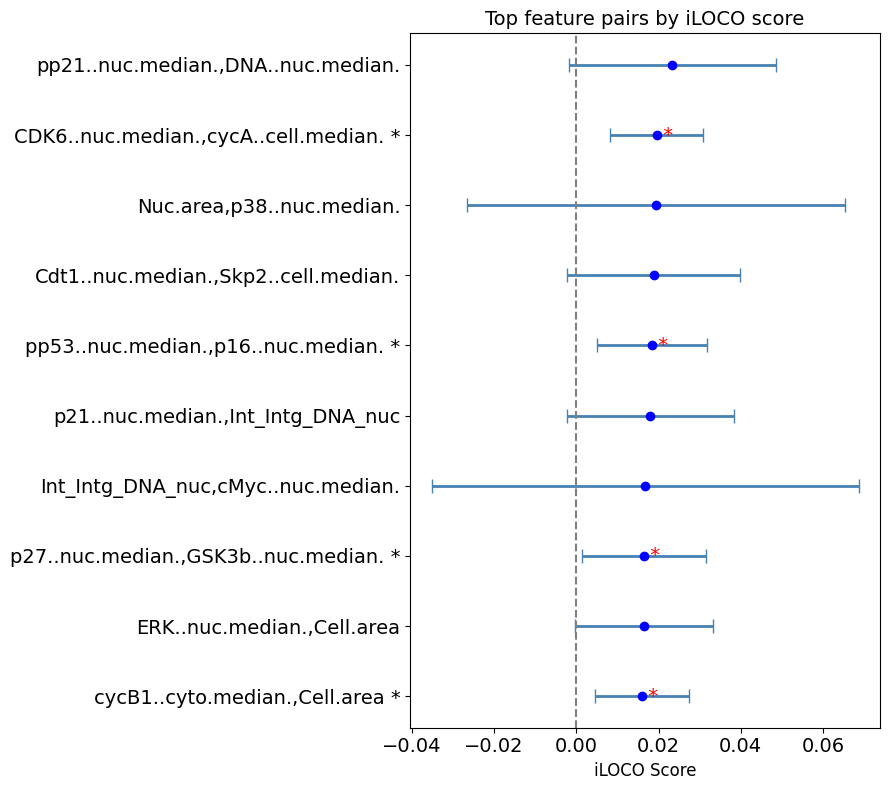

In [15]:
import matplotlib.pyplot as plt
top_20 = df.nlargest(10, "iloco")

# Plot
# Copy feature names so we can modify them without affecting the original DataFrame
ytick_labels = top_20["features"].copy()

# Add star next to feature names if CI does not include zero
for i, (iloco, ci) in enumerate(zip(top_20["iloco"], top_20["ci"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["iloco"],
    top_20["features"],
    xerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)  # Rotate x-axis labels vertically
plt.xlabel("iLOCO Score", fontsize=12)
plt.title("Top feature pairs by iLOCO score", fontsize=14)

# Add stars for scores whose confidence intervals do not include 0
for i, (iloco, ci, features) in enumerate(zip(top_20["iloco"], top_20["ci"], top_20["features"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(iloco, features, " *", color='red', fontsize=14, va='center')

plt.yticks(ticks=top_20["features"], labels=ytick_labels, fontsize=14)

plt.gca().invert_yaxis()  # Reverse y-axis

plt.tight_layout()
plt.show()

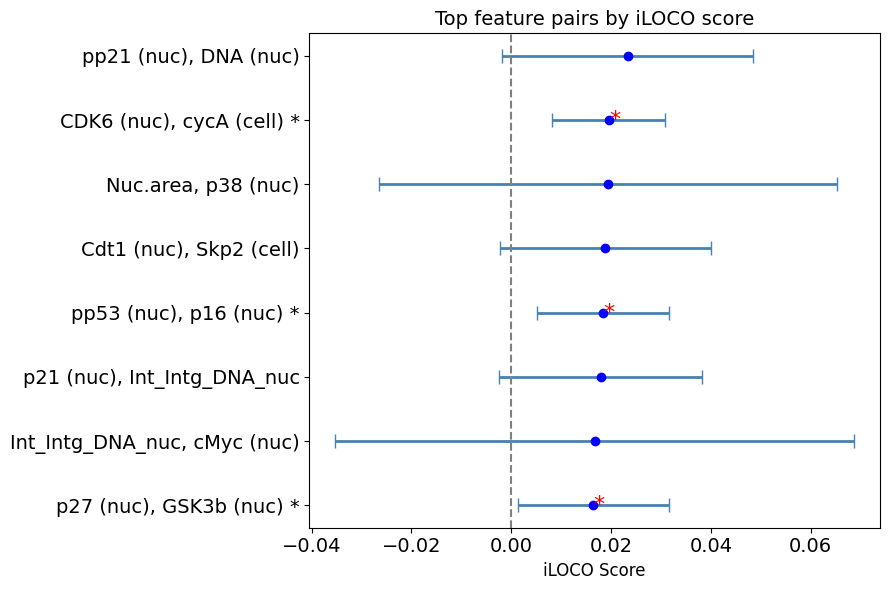

In [25]:
import matplotlib.pyplot as plt
import re

# --- Helper function to make labels human-readable ---
def clean_feature_label(feature_str):
    """
    Convert strings like:
      'pp21..nuc.median.,DNA..nuc.median.'
    into:
      'pp21 (nuc), DNA (nuc)'
    """
    parts = feature_str.strip().split(',')
    cleaned_parts = []
    for part in parts:
        # Match patterns like 'gene..location.median.'
        match = re.match(r"([A-Za-z0-9_]+)\.\.([A-Za-z0-9_]+)\.median\.*", part.strip())
        if match:
            gene, loc = match.groups()
            cleaned_parts.append(f"{gene} ({loc})")
        else:
            # Handle single features like 'Nuc.area'
            cleaned_parts.append(part.strip())
    return ", ".join(cleaned_parts)


# --- Select top features ---
top_20 = df.nlargest(8, "iloco").copy()

# Clean labels for plotting
ytick_labels = top_20["features"].apply(clean_feature_label)

# Add a star in the label for significant features (CI not overlapping 0)
for i, (iloco, ci) in enumerate(zip(top_20["iloco"], top_20["ci"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

# --- Plot ---
plt.figure(figsize=(9, 6))
plt.errorbar(
    top_20["iloco"],
    top_20["features"],
    xerr=top_20["ci"],
    fmt='o',
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)
plt.xlabel("iLOCO Score", fontsize=12)
plt.title("Top feature pairs by iLOCO score", fontsize=14)

# --- Add red stars next to significant points ---
for i, (iloco, ci, features) in enumerate(zip(top_20["iloco"], top_20["ci"], top_20["features"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(iloco, features, "*", color='red', fontsize=16, va='center', ha='left')

# --- Apply cleaned labels ---
plt.yticks(ticks=top_20["features"], labels=ytick_labels, fontsize=14)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


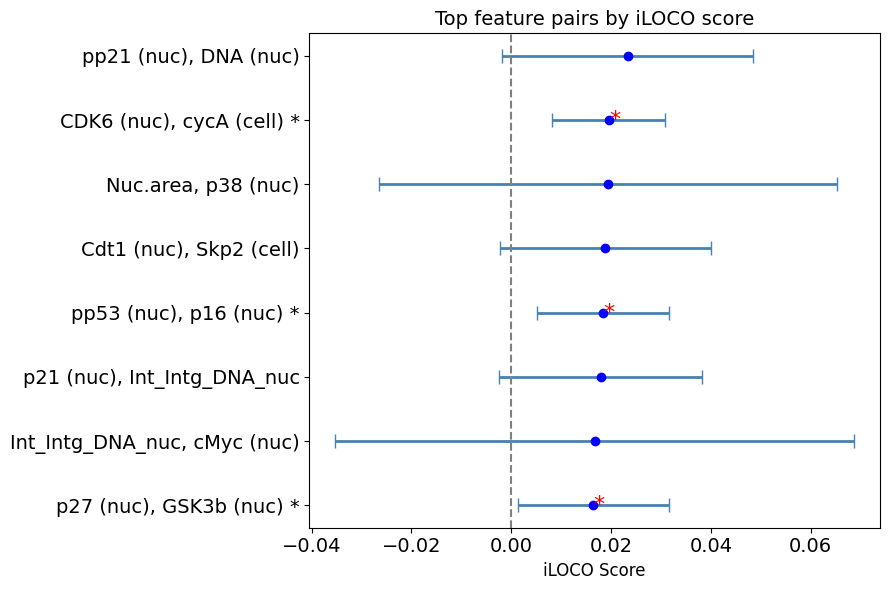

In [ ]:
import matplotlib.pyplot as plt
import re

# --- Helper function to make labels human-readable ---
def clean_feature_label(feature_str):
    """
    Convert strings like:
      'pp21..nuc.median.,DNA..nuc.median.'
    into:
      'pp21 (nuc), DNA (nuc)'
    """
    parts = feature_str.strip().split(',')
    cleaned_parts = []
    for part in parts:
        # Match patterns like 'gene..location.median.'
        match = re.match(r"([A-Za-z0-9_]+)\.\.([A-Za-z0-9_]+)\.median\.*", part.strip())
        if match:
            gene, loc = match.groups()
            cleaned_parts.append(f"{gene} ({loc})")
        else:
            # Handle single features like 'Nuc.area'
            cleaned_parts.append(part.strip())
    return ", ".join(cleaned_parts)


# --- Select top features ---
top_20 = df.nlargest(8, "iloco").copy()

# Clean labels for plotting
ytick_labels = top_20["features"].apply(clean_feature_label)

# Add a star in the label for significant features (CI not overlapping 0)
for i, (iloco, ci) in enumerate(zip(top_20["iloco"], top_20["ci"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

# --- Plot ---
plt.figure(figsize=(9, 6))
plt.errorbar(
    top_20["iloco"],
    top_20["features"],
    xerr=top_20["ci"],
    fmt='o',
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)
plt.xlabel("iLOCO Score", fontsize=12)
plt.title("Top feature pairs by iLOCO score", fontsize=14)

# --- Add red stars next to significant points ---
for i, (iloco, ci, features) in enumerate(zip(top_20["iloco"], top_20["ci"], top_20["features"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(iloco, features, "*", color='red', fontsize=16, va='center', ha='left')

# --- Apply cleaned labels ---
plt.yticks(ticks=top_20["features"], labels=ytick_labels, fontsize=14)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


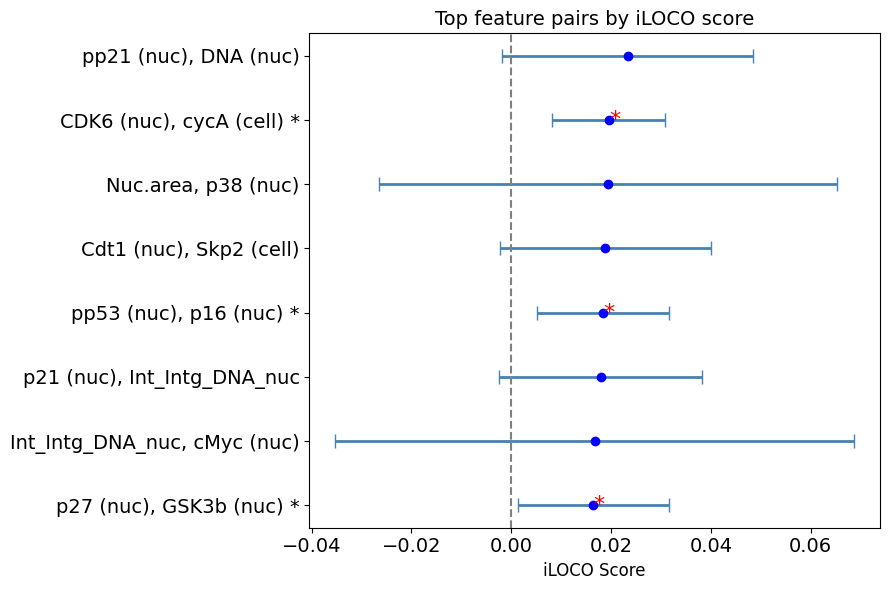

In [ ]:
import matplotlib.pyplot as plt
import re

# --- Helper function to make labels human-readable ---
def clean_feature_label(feature_str):
    """
    Convert strings like:
      'pp21..nuc.median.,DNA..nuc.median.'
    into:
      'pp21 (nuc), DNA (nuc)'
    """
    parts = feature_str.strip().split(',')
    cleaned_parts = []
    for part in parts:
        # Match patterns like 'gene..location.median.'
        match = re.match(r"([A-Za-z0-9_]+)\.\.([A-Za-z0-9_]+)\.median\.*", part.strip())
        if match:
            gene, loc = match.groups()
            cleaned_parts.append(f"{gene} ({loc})")
        else:
            # Handle single features like 'Nuc.area'
            cleaned_parts.append(part.strip())
    return ", ".join(cleaned_parts)


# --- Select top features ---
top_20 = df.nlargest(8, "iloco").copy()

# Clean labels for plotting
ytick_labels = top_20["features"].apply(clean_feature_label)

# Add a star in the label for significant features (CI not overlapping 0)
for i, (iloco, ci) in enumerate(zip(top_20["iloco"], top_20["ci"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

# --- Plot ---
plt.figure(figsize=(9, 6))
plt.errorbar(
    top_20["iloco"],
    top_20["features"],
    xerr=top_20["ci"],
    fmt='o',
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)
plt.xlabel("iLOCO Score", fontsize=12)
plt.title("Top feature pairs by iLOCO score", fontsize=14)

# --- Add red stars next to significant points ---
for i, (iloco, ci, features) in enumerate(zip(top_20["iloco"], top_20["ci"], top_20["features"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(iloco, features, "*", color='red', fontsize=16, va='center', ha='left')

# --- Apply cleaned labels ---
plt.yticks(ticks=top_20["features"], labels=ytick_labels, fontsize=14)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


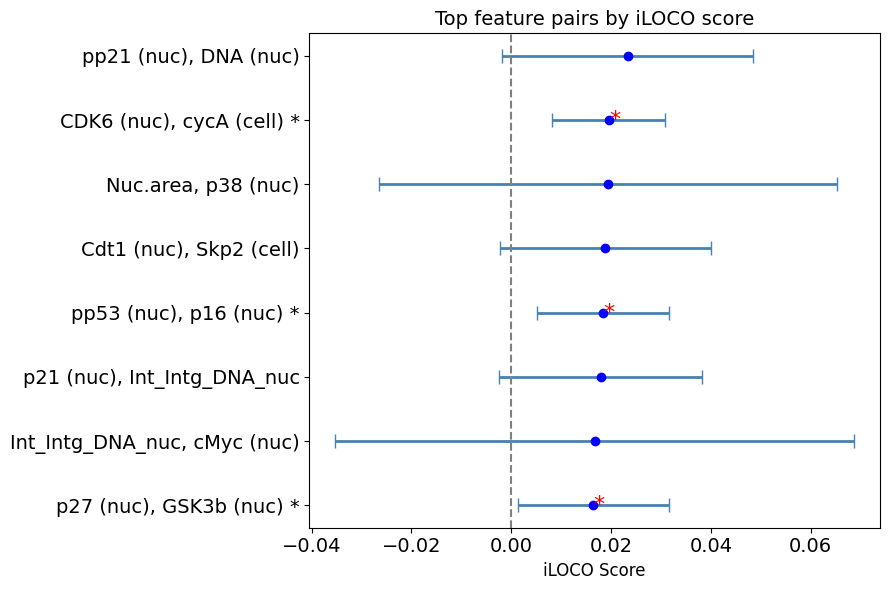

In [ ]:
import matplotlib.pyplot as plt
import re

# --- Helper function to make labels human-readable ---
def clean_feature_label(feature_str):
    """
    Convert strings like:
      'pp21..nuc.median.,DNA..nuc.median.'
    into:
      'pp21 (nuc), DNA (nuc)'
    """
    parts = feature_str.strip().split(',')
    cleaned_parts = []
    for part in parts:
        # Match patterns like 'gene..location.median.'
        match = re.match(r"([A-Za-z0-9_]+)\.\.([A-Za-z0-9_]+)\.median\.*", part.strip())
        if match:
            gene, loc = match.groups()
            cleaned_parts.append(f"{gene} ({loc})")
        else:
            # Handle single features like 'Nuc.area'
            cleaned_parts.append(part.strip())
    return ", ".join(cleaned_parts)


# --- Select top features ---
top_20 = df.nlargest(8, "iloco").copy()

# Clean labels for plotting
ytick_labels = top_20["features"].apply(clean_feature_label)

# Add a star in the label for significant features (CI not overlapping 0)
for i, (iloco, ci) in enumerate(zip(top_20["iloco"], top_20["ci"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

# --- Plot ---
plt.figure(figsize=(9, 6))
plt.errorbar(
    top_20["iloco"],
    top_20["features"],
    xerr=top_20["ci"],
    fmt='o',
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)
plt.xlabel("iLOCO Score", fontsize=12)
plt.title("Top feature pairs by iLOCO score", fontsize=14)

# --- Add red stars next to significant points ---
for i, (iloco, ci, features) in enumerate(zip(top_20["iloco"], top_20["ci"], top_20["features"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(iloco, features, "*", color='red', fontsize=16, va='center', ha='left')

# --- Apply cleaned labels ---
plt.yticks(ticks=top_20["features"], labels=ytick_labels, fontsize=14)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


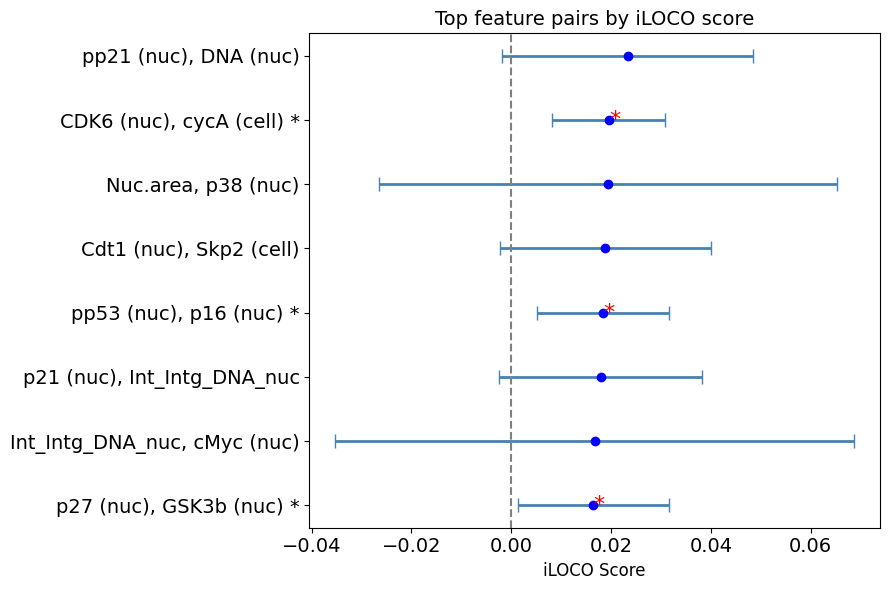

In [ ]:
import matplotlib.pyplot as plt
import re

# --- Helper function to make labels human-readable ---
def clean_feature_label(feature_str):
    """
    Convert strings like:
      'pp21..nuc.median.,DNA..nuc.median.'
    into:
      'pp21 (nuc), DNA (nuc)'
    """
    parts = feature_str.strip().split(',')
    cleaned_parts = []
    for part in parts:
        # Match patterns like 'gene..location.median.'
        match = re.match(r"([A-Za-z0-9_]+)\.\.([A-Za-z0-9_]+)\.median\.*", part.strip())
        if match:
            gene, loc = match.groups()
            cleaned_parts.append(f"{gene} ({loc})")
        else:
            # Handle single features like 'Nuc.area'
            cleaned_parts.append(part.strip())
    return ", ".join(cleaned_parts)


# --- Select top features ---
top_20 = df.nlargest(8, "iloco").copy()

# Clean labels for plotting
ytick_labels = top_20["features"].apply(clean_feature_label)

# Add a star in the label for significant features (CI not overlapping 0)
for i, (iloco, ci) in enumerate(zip(top_20["iloco"], top_20["ci"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

# --- Plot ---
plt.figure(figsize=(9, 6))
plt.errorbar(
    top_20["iloco"],
    top_20["features"],
    xerr=top_20["ci"],
    fmt='o',
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)
plt.xlabel("iLOCO Score", fontsize=12)
plt.title("Top feature pairs by iLOCO score", fontsize=14)

# --- Add red stars next to significant points ---
for i, (iloco, ci, features) in enumerate(zip(top_20["iloco"], top_20["ci"], top_20["features"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(iloco, features, "*", color='red', fontsize=16, va='center', ha='left')

# --- Apply cleaned labels ---
plt.yticks(ticks=top_20["features"], labels=ytick_labels, fontsize=14)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


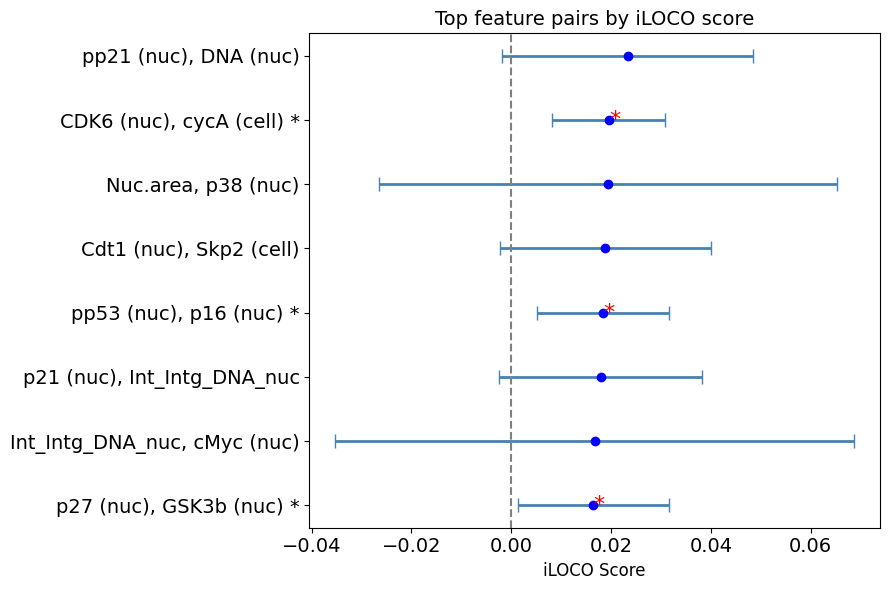

In [ ]:
import matplotlib.pyplot as plt
import re

# --- Helper function to make labels human-readable ---
def clean_feature_label(feature_str):
    """
    Convert strings like:
      'pp21..nuc.median.,DNA..nuc.median.'
    into:
      'pp21 (nuc), DNA (nuc)'
    """
    parts = feature_str.strip().split(',')
    cleaned_parts = []
    for part in parts:
        # Match patterns like 'gene..location.median.'
        match = re.match(r"([A-Za-z0-9_]+)\.\.([A-Za-z0-9_]+)\.median\.*", part.strip())
        if match:
            gene, loc = match.groups()
            cleaned_parts.append(f"{gene} ({loc})")
        else:
            # Handle single features like 'Nuc.area'
            cleaned_parts.append(part.strip())
    return ", ".join(cleaned_parts)


# --- Select top features ---
top_20 = df.nlargest(8, "iloco").copy()

# Clean labels for plotting
ytick_labels = top_20["features"].apply(clean_feature_label)

# Add a star in the label for significant features (CI not overlapping 0)
for i, (iloco, ci) in enumerate(zip(top_20["iloco"], top_20["ci"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

# --- Plot ---
plt.figure(figsize=(9, 6))
plt.errorbar(
    top_20["iloco"],
    top_20["features"],
    xerr=top_20["ci"],
    fmt='o',
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)
plt.xlabel("iLOCO Score", fontsize=12)
plt.title("Top feature pairs by iLOCO score", fontsize=14)

# --- Add red stars next to significant points ---
for i, (iloco, ci, features) in enumerate(zip(top_20["iloco"], top_20["ci"], top_20["features"])):
    lower = iloco - ci
    upper = iloco + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(iloco, features, "*", color='red', fontsize=16, va='center', ha='left')

# --- Apply cleaned labels ---
plt.yticks(ticks=top_20["features"], labels=ytick_labels, fontsize=14)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [6]:
df = exhaustive_regression_full(X, y)

In [ ]:
n_sig = df["bonf_significant"].sum()
print(f"Number of Bonferroni-significant interactions: {n_sig}")

KeyError: 'interaction_pval'

In [ ]:
top20 = df.sort_values('interaction_pval_bonf').head(20)
top20

TEST (cancer)

In [47]:
import re
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

def mnlogit_formula_all_interactions(df, X, target, alpha=0.1, collapse="min"):
    """
    Fit a multinomial logit model with all main effects and pairwise interactions,
    then test interaction significance with Bonferroni correction.

    Parameters
    ----------
    df : pd.DataFrame
        Full dataset.
    X : list
        List of predictor columns.
    target : str
        Target column (categorical).
    alpha : float
        Significance threshold for Bonferroni correction.
    collapse : {'min', 'mean'}
        How to collapse per-category p-values into one per interaction.

    Returns
    -------
    out : pd.DataFrame
        Interaction terms, raw p-values, Bonferroni-corrected p-values, significance.
    result : statsmodels.discrete.discrete_model.MNLogitResults
        Fitted MNLogit model.
    """

    # --- Clean column names for Patsy ---
    rename_map = {c: re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in df.columns}
    df_safe = df.rename(columns=rename_map)
    target_safe = rename_map[target]
    predictors = [rename_map[c] for c in X]

    # --- Build formula with pairwise interactions ---
    rhs = " + ".join(predictors)
    formula = f"{target_safe} ~ ({rhs}) ** 2"

    # --- Fit multinomial logit model ---
    model = smf.mnlogit(formula, data=df_safe)
    result = model.fit(disp=False)

    # --- Extract interaction rows ---
    pvals = result.pvalues

    # Normal case: multiple categories → DataFrame
    mask = pvals.index.str.contains(":")
    interaction_pvals = pvals.loc[mask]

    # Collapse per-category p-values
    collapsed = interaction_pvals.min(axis=1).to_frame(name="pval")

    collapsed["term"] = collapsed.index

    # --- Bonferroni correction ---
    m = collapsed["pval"].notna().sum()
    if m > 0:
        collapsed["pval_bonf"] = collapsed["pval"].apply(lambda p: min(1.0, p * m) if pd.notna(p) else np.nan)
        collapsed["bonf_significant"] = collapsed["pval_bonf"] < alpha
    else:
        collapsed["pval_bonf"] = np.nan
        collapsed["bonf_significant"] = False

    collapsed.attrs["n_tests"] = int(m)
    collapsed.attrs["alpha"] = float(alpha)

    out = collapsed.reset_index(drop=True).sort_values("pval")

    return out, result


In [51]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/T47D.csv")

# Separate features and target
X = df.drop(columns=['phase'])
#X = X.select_dtypes(include=['number'])
y = df['Metadata_well']

In [52]:
results_df, model = mnlogit_formula_all_interactions(df, X, 'phase', alpha=0.1)

ValueError: endog has evaluated to an array with multiple columns that has shape (64502, 4). This occurs when the variable converted to endog is non-numeric (e.g., bool or str).

In [50]:
print(model.summary())

                          MNLogit Regression Results                          
Dep. Variable:          Metadata_well   No. Observations:                64502
Model:                        MNLogit   Df Residuals:                    63406
Method:                           MLE   Df Model:                         1092
Date:                Sun, 26 Oct 2025   Pseudo R-squ.:                     nan
Time:                        22:41:55   Log-Likelihood:                    nan
converged:                       True   LL-Null:                   -1.0294e+05
Covariance Type:            nonrobust   LLR p-value:                       nan
                                                  Metadata_well=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                nan        nan        nan  

In [14]:
n_sig = df["bonf_significant"].sum()
print(f"Number of Bonferroni-significant interactions: {n_sig}")

Number of Bonferroni-significant interactions: 98


In [ ]:
top20 = df.sort_values('interaction_pval_bonf').head(20)
top20

In [37]:
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/cancer_iloco_decisionTree.csv")
significant_count = (df["scores"] - df["ci"] > 0).sum()
print(f"Number of significant interactions (p < 0.1): {significant_count}")

Number of significant interactions (p < 0.1): 47


In [38]:
top_20 = df.nlargest(20, "scores")
top_20

,feature,scores,ci
182,Intensity_MedianIntensity_cycD1 & Intensity_MedianIntensity_pRB,0.007073,0.001302
87,Intensity_MedianIntensity_Cdh1 & Intensity_MedianIntensity_ER,0.005530,0.002360
122,Intensity_MedianIntensity_E2F1 & Intensity_MedianIntensity_pRB,0.003867,0.000771
0,AreaShape_Area & Intensity_IntegratedIntensity_DNA,0.003422,0.000552
106,Intensity_MedianIntensity_Cdt1 & Intensity_MedianIntensity_cycB1,0.003154,0.000785
179,Intensity_MedianIntensity_cycB1 & pRB_over_RB,0.002977,0.000710
178,Intensity_MedianIntensity_cycB1 & Intensity_MedianIntensity_pRB,0.002957,0.000710
35,Intensity_IntegratedIntensity_DNA & Intensity_MedianIntensity_pRB,0.002782,0.000511
184,Intensity_MedianIntensity_cycE & Intensity_MedianIntensity_p21,0.002712,0.000804
18,AreaShape_Area & pRB_over_RB,0.002539,0.000552


DOSE DEPENDANT

In [31]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/T47D.csv")

# Separate features and target
X = df.drop(columns=['phase'])
X = X.select_dtypes(include=['number'])
y = df['phase']

In [32]:
df = exhaustive_regression(X, y, categorical_target=True)

/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3028: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3028: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
  eXB = np.column

In [33]:
n_sig = df["bonf_significant"].sum()
print(f"Number of Bonferroni-significant interactions: {n_sig}")

Number of Bonferroni-significant interactions: 446


In [ ]:
top20 = df.sort_values('interaction_pval_bonf').head(20)
top20

,feature1,feature2,model,class,interaction_coef,interaction_pval
462,Intensity_MedianIntensity_Ki67,Metadata_well,MNLogit,G0,0.007942,0.000000e+00
1,AreaShape_Area,Intensity_IntegratedIntensity_DNA,MNLogit,G1,-1.149329,0.000000e+00
2,AreaShape_Area,Intensity_IntegratedIntensity_DNA,MNLogit,G2/M,-0.967918,0.000000e+00
439,Intensity_MedianIntensity_Ki67,Intensity_MedianIntensity_Skp2,MNLogit,G1,-0.473036,0.000000e+00
315,Intensity_MedianIntensity_Cdt1,Intensity_MedianIntensity_E2F1,MNLogit,G0,-0.407602,0.000000e+00
321,Intensity_MedianIntensity_Cdt1,Intensity_MedianIntensity_Ki67,MNLogit,G0,-0.794763,0.000000e+00
322,Intensity_MedianIntensity_Cdt1,Intensity_MedianIntensity_Ki67,MNLogit,G1,-1.073437,0.000000e+00
440,Intensity_MedianIntensity_Ki67,Intensity_MedianIntensity_Skp2,MNLogit,G2/M,-0.681807,0.000000e+00
327,Intensity_MedianIntensity_Cdt1,Intensity_MedianIntensity_RB,MNLogit,G0,-0.404397,0.000000e+00
330,Intensity_MedianIntensity_Cdt1,Intensity_MedianIntensity_Skp2,MNLogit,G0,-0.930711,0.000000e+00


In [20]:
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/cancer_iloco_ensemble.csv")
significant_count = (df["scores"] - df["ci"] > 0).sum()
print(f"Number of significant interactions (p < 0.1): {significant_count}")

Number of significant interactions (p < 0.1): 82


In [15]:
top_20 = df.nlargest(20, "scores")
top_20

,feature,scores,ci
209,pRB_over_RB & Metadata_well,0.048161,0.002420
38,Intensity_IntegratedIntensity_DNA & Metadata_well,0.026614,0.002364
208,Intensity_MedianIntensity_pRB & Metadata_well,0.014119,0.000568
171,Intensity_MedianIntensity_RB & Intensity_MedianIntensity_pRB,0.010555,0.000386
173,Intensity_MedianIntensity_RB & Metadata_well,0.003133,0.000386
107,Intensity_MedianIntensity_Cdt1 & Intensity_MedianIntensity_Ki67,0.002143,0.000365
163,Intensity_MedianIntensity_PR & pRB_over_RB,0.002139,0.000217
144,Intensity_MedianIntensity_Ki67 & Intensity_MedianIntensity_PR,0.002053,0.000456
103,Intensity_MedianIntensity_Cdh1 & pRB_over_RB,0.001955,0.000385
193,Intensity_MedianIntensity_cycB1 & pRB_over_RB,0.001893,0.000545
